# Project Overview

This project implements a **BERT-based sentiment classifier** on movie reviews and a **content-based recommendation module** that recommends movies (or reviews) based on **positive reviews only**, using **LoRA fine-tuning** for efficiency.

Main goals:

1. **Sentiment Classification**  
   - Input: movie review text  
   - Output: label `1` (positive) or `0` (negative)  
   - Model: `bert-base-uncased` fine-tuned with **LoRA** for sequence classification.

2. **Positive-Review-based Recommendation**  
   - Use the **LoRA-finetuned BERT encoder** to encode reviews as vectors.
   - Build an embedding corpus for **only positive reviews** from `train.csv`.
   - Given a new query review, compute its embedding and find the **most similar positive reviews** using cosine similarity.

---

# Directory Structure

Example structure:

```text
7240_ResProject/
│
├─ data/
│   ├─ train.csv              # id, text, label (1 = positive, 0 = negative)
│   ├─ test.csv               # id, text (for inference / submission)
│   ├─ sample_submission.csv  # example submission format
│   └─ positive_corpus_embeddings_lora.pt  # generated positive-review embeddings
│
├─ flaskr/                    # (optional) Flask API code
│   └─ ...
│
├─ src/
│   ├─ model/
│   │   ├─ bert_sentiment_lora/   # saved LoRA-finetuned model & tokenizer
│   │   └─ ...                    # other model files
│   │
│   └─ train/
│       ├─ train_lora.py          # LoRA fine-tuning script
│       ├─ recommend_pos_lora.py  # positive-review recommendation
│       └─ ...                    # other training / inference scripts
│
└─ README.md
```
# Data Format
data/train.csv:
```text
id,text,label
0,"All in all, don't expect much and you won't be disappointed...",0
1,"If there's one good suspenseful film, this is one of them...",1
2,"I am surprised that so many comments about this film are positive...",0
'''
```
id : unique identifier of the sample；text : raw movie review text；label : 1 for positive, 0 for negative sentiment

# Environment & Dependencies

Install Key Python packages: (adapt as needed):
```code
pip install torch transformers peft scikit-learn pandas numpy
```
# LoRA Fine-tuning for Sentiment Classification
Script: src/train/train_lora.py (or equivalent Kaggle script)

Main steps:

- Load train.csv and split into train/validation sets.

- Tokenize texts with BertTokenizer.from_pretrained("bert-base-uncased").

- Create a TextDataset wrapping tokenized inputs and labels.

- Load base BertForSequenceClassification with num_labels=2.

Configure LoRA:

```code
lora_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,
    r=8,
    lora_alpha=16,
    lora_dropout=0.1,
    target_modules=["query", "value"]
)
model = get_peft_model(base_model, lora_config)
```
- Define metrics (accuracy, precision, recall, f1).

- Set TrainingArguments and use Trainer to train.

- Save model and tokenizer to checkpoints/bert_sentiment_lora (or your chosen path).

Typical run:

```code
python -m src.train.train_lora
```
After training, the sentiment model should:
- Input: review text
- Output: predicted label 0 or 1 for sentiment classification.
# Using the LoRA Model for Inference
Example (simplified):

```code
from transformers import BertTokenizer, BertForSequenceClassification
from peft import PeftModel
import torch

MODEL_DIR = "checkpoints/bert_sentiment_lora"

def load_lora_model():
    base_model = BertForSequenceClassification.from_pretrained(
        "bert-base-uncased", num_labels=2
    )
    model = PeftModel.from_pretrained(base_model, MODEL_DIR)
    tokenizer = BertTokenizer.from_pretrained(MODEL_DIR)
    device = "cuda" if torch.cuda.is_available() else "cpu"
    model.to(device)
    model.eval()
    return model, tokenizer, device

def predict(text: str) -> int:
    model, tokenizer, device = load_lora_model()
    enc = tokenizer(
        [text],
        truncation=True,
        padding=True,
        max_length=256,
        return_tensors="pt",
    )
    enc = {k: v.to(device) for k, v in enc.items()}
    with torch.no_grad():
        logits = model(**enc).logits
        pred = torch.argmax(logits, dim=-1).item()
    return int(pred)  # 0 or 1
```
# Building Positive-Review Embedding Corpus (LoRA)
Script: src/train/recommend_pos_lora.py

Purpose:

- Build an embedding corpus only from positive reviews (label == 1).
- Reuse the LoRA-finetuned BERT encoder to obtain [CLS] embeddings.

Key steps (in build_positive_corpus_embeddings_lora()):

- Load LoRA model + tokenizer:
- Read data/train.csv and filter label == 1.
- For each positive review, encode with:

- Save a dictionary to data/positive_corpus_embeddings_lora.pt:
- Run once:
```code
python -m src.train.recommend_pos_lora
# (uncomment build_positive_corpus_embeddings_lora() in __main__ first)
```
# Positive-Only Recommendation via Similarity
Function: recommend_from_positive_lora(query_text, top_k=5)

Workflow:

- Load LoRA model + tokenizer.

- Load positive_corpus_embeddings_lora.pt (precomputed positive-review embeddings).

- Encode the query text with the same LoRA BERT encoder to get q_vec.

- Compute cosine similarity between q_vec and all positive-review embeddings:
```code
q_vec = F.normalize(q_vec, p=2, dim=-1)     # [1, hidden]
c_vec = F.normalize(corpus_embeddings, p=2, dim=-1)  # [N, hidden]
sims = torch.mm(q_vec, c_vec.T).squeeze(0) # [N]
```
- Take top-k indices and return their id, text, and similarity score.

Example usage:

```code
from src.train.recommend_pos_lora import recommend_from_positive_lora

query = "This movie is really heartwarming and beautiful."
results = recommend_from_positive_lora(query, top_k=5)

for r in results:
    print("id:", r["id"], "score:", r["score"])
    print(r["text"][:200], "...")
    print("=" * 40)
```
This effectively recommends the most semantically similar positive reviews to the input query, which can be mapped to movies if id corresponds to movie IDs.

# Possible Extensions
- Add movie_id column to train.csv and store it in the embedding corpus to recommend movies, not just texts.
- Wrap sentiment prediction + recommendation logic into a Flask API in flaskr/.
- Add evaluation scripts (accuracy/F1 on a hold-out set, NDCG/MRR for recommendation quality).
- Try other backbones (e.g., roberta-base) or different LoRA configs.
# Quick Start
- Place train.csv in data/ with columns: id, text, label.

- Install dependencies.

- Train LoRA sentiment model:

```code
python -m src.train.train_lora
```
- Build positive-review embedding corpus:
```code
python -m src.train.recommend_pos_lora
# with build_positive_corpus_embeddings_lora() enabled once
```
- Use recommend_from_positive_lora to get recommendations based on new reviews.

In [2]:
import os
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

import torch
from torch.utils.data import Dataset

from transformers import (
    BertTokenizer,
    BertForSequenceClassification,
    Trainer,
    TrainingArguments,
)

from peft import LoraConfig, get_peft_model, TaskType
ROOT_DIR = os.path.dirname(os.path.dirname(os.path.dirname('/kaggle/input')))
print(ROOT_DIR)
DATA_DIR = "/kaggle/input/competitions/7-30-imdb"
print(DATA_DIR)
MODEL_NAME = "bert-base-uncased"
OUTPUT_DIR = "/kaggle/working/bert_sentiment_lora"
csv_path = os.path.join(DATA_DIR, "train.csv")
df = pd.read_csv(csv_path)

texts = df["text"].astype(str).tolist()
labels = df["label"].astype(int).tolist()   # 0/1

print(f"Loaded {len(texts)} samples from train.csv")

X_train, X_val, y_train, y_val = train_test_split(
    texts, labels, test_size=0.2, random_state=42, stratify=labels
)

tokenizer = BertTokenizer.from_pretrained(MODEL_NAME)

class TextDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=256):
        self.encodings = tokenizer(
            texts,
            truncation=True,
            padding=True,
            max_length=max_len
        )
        self.labels = labels

    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = TextDataset(X_train, y_train, tokenizer)
val_dataset   = TextDataset(X_val,   y_val,   tokenizer)

base_model = BertForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2
)

lora_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,  
    r=8,
    lora_alpha=16,
    lora_dropout=0.1,
    target_modules=["query", "value"]  
)

model = get_peft_model(base_model, lora_config)
model.print_trainable_parameters()  

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    acc = accuracy_score(labels, preds)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, preds, average="binary", pos_label=1
    )
    return {
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1,
    }

training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    num_train_epochs=32,
    per_device_train_batch_size=64,
    per_device_eval_batch_size=64,
    learning_rate=2e-4,
    weight_decay=0.01,
    logging_steps=50,
    fp16=True,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
)

trainer.train()

trainer.save_model(OUTPUT_DIR)
tokenizer.save_pretrained(OUTPUT_DIR)
print(f"LoRA sentiment model saved to {OUTPUT_DIR}")


/
/kaggle/input/competitions/7-30-imdb
Loaded 47000 samples from train.csv


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

...

trainable params: 296,450 || all params: 109,780,228 || trainable%: 0.2700


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Step,Training Loss
50,1.308190
100,0.798214
150,0.603269
200,0.554904
250,0.529346
300,0.524989
350,0.472016
400,0.518866
450,0.494170
500,0.449582


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector

LoRA sentiment model saved to /kaggle/working/bert_sentiment_lora


In [10]:
import os
import torch
from transformers import BertTokenizer, BertForSequenceClassification
from peft import PeftModel

ROOT_DIR = os.getcwd()
MODEL_DIR = os.path.join(ROOT_DIR, "src/model", "bert_sentiment_lora")
print(MODEL_DIR)

def load_lora_model():
    base_model = BertForSequenceClassification.from_pretrained(
        "bert-base-uncased",
        num_labels=2
    )
    model = PeftModel.from_pretrained(base_model, MODEL_DIR)
    tokenizer = BertTokenizer.from_pretrained(MODEL_DIR)
    device = "cuda" if torch.cuda.is_available() else "cpu"
    model.to(device)
    model.eval()
    return model, tokenizer, device

def predict(text: str) -> int:
    model, tokenizer, device = load_lora_model()
    enc = tokenizer(
        [text],
        truncation=True,
        padding=True,
        max_length=256,
        return_tensors="pt"
    )
    enc = {k: v.to(device) for k, v in enc.items()}
    with torch.no_grad():
        logits = model(**enc).logits
        pred = torch.argmax(logits, dim=-1).item()
    return int(pred)   # 0 or 1

E:\工作目录\大学\daai\class\semester_2\7240_Recommender_Systems\7240_ResProject\src/model\bert_sentiment_lora


In [11]:
print(predict("This movie is absolutely wonderful!"))

Loading weights: 100%|█████████████████████████████████████████████████████████████| 199/199 [00:00<00:00, 6996.48it/s]
BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initializ

1


In [12]:
import os
import torch
import torch.nn.functional as F
import pandas as pd

from transformers import BertTokenizer, BertForSequenceClassification
from peft import PeftModel


# Project root and data paths
ROOT_DIR = os.getcwd()
DATA_DIR = os.path.join(ROOT_DIR, "data")

# Directory where the LoRA fine-tuned model is saved

LORA_MODEL_DIR = os.path.join(ROOT_DIR, "src/model", "bert_sentiment_lora")
print(LORA_MODEL_DIR)
# Path to store precomputed positive-review embeddings
CORPUS_PATH = os.path.join(DATA_DIR, "positive_corpus_embeddings_lora.pt")


def load_lora_model():
    """
    Load the base BERT classification model and apply LoRA weights,
    then load the tokenizer.
    """
    device = "cuda" if torch.cuda.is_available() else "cpu"

    # 1) Load base BERT classification model
    base_model = BertForSequenceClassification.from_pretrained(
        "bert-base-uncased",
        num_labels=2,
    )
    # 2) Load LoRA adapter weights
    model = PeftModel.from_pretrained(base_model, LORA_MODEL_DIR)
    model.to(device)
    model.eval()

    # 3) Load tokenizer from the same directory (fallback to base tokenizer)
    if os.path.exists(LORA_MODEL_DIR):
        tokenizer = BertTokenizer.from_pretrained(LORA_MODEL_DIR)
    else:
        tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

    return model, tokenizer, device


def encode_texts_with_lora(
    model,
    tokenizer,
    texts,
    device,
    max_len=256,
    batch_size=32,
):
    """
    Encode multiple texts using the BERT encoder part of the LoRA model.
    Returns a tensor of shape [N, hidden].

    Note: we only use the BERT encoder and take [CLS] embeddings,
    ignoring the classification head.
    """
    model.eval()
    all_vecs = []

    with torch.no_grad():
        for i in range(0, len(texts), batch_size):
            batch_texts = texts[i: i + batch_size]
            enc = tokenizer(
                batch_texts,
                truncation=True,
                padding="max_length",
                max_length=max_len,
                return_tensors="pt",
            )
            input_ids = enc["input_ids"].to(device)
            attention_mask = enc["attention_mask"].to(device)

            # Use only the BERT encoder (ignore classifier head)
            outputs = model.base_model.bert(
                input_ids=input_ids,
                attention_mask=attention_mask,
            )
            cls = outputs.last_hidden_state[:, 0, :]  # [B, hidden]
            all_vecs.append(cls.cpu())

    return torch.cat(all_vecs, dim=0)  # [N, hidden]


def build_positive_corpus_embeddings_lora():
    """
    1. Read data/train.csv
    2. Filter rows where label == 1 (positive reviews)
    3. Encode texts with the LoRA BERT encoder to obtain embeddings
    4. Save them to positive_corpus_embeddings_lora.pt
    """
    model, tokenizer, device = load_lora_model()

    df = pd.read_csv(os.path.join(DATA_DIR, "train.csv"))
    pos_df = df[df["label"] == 1].reset_index(drop=True)

    if len(pos_df) == 0:
        raise ValueError("No samples with label == 1 found in train.csv.")

    texts = pos_df["text"].astype(str).tolist()
    ids = pos_df["id"].tolist()

    print(f"Number of positive reviews: {len(texts)}. Start encoding (LoRA model)...")

    embeddings = encode_texts_with_lora(
        model, tokenizer, texts, device,
        max_len=256, batch_size=32
    )

    torch.save(
        {
            "embeddings": embeddings,  # [N, hidden]
            "ids": ids,
            "texts": texts,
        },
        CORPUS_PATH,
    )
    print(f"Positive-review embeddings saved to: {CORPUS_PATH}")


def recommend_from_positive_lora(query_text, top_k=5):
    """
    Given a new review text, encode it with the LoRA model and
    find the top_k most similar reviews in the precomputed positive-review corpus.

    Returns:
        List of dicts: [{'id':..., 'text':..., 'score':...}, ...]
    """
    model, tokenizer, device = load_lora_model()

    if not os.path.exists(CORPUS_PATH):
        raise FileNotFoundError(
            f"{CORPUS_PATH} not found. Please run build_positive_corpus_embeddings_lora() first."
        )

    data = torch.load(CORPUS_PATH)
    corpus_embeddings = data["embeddings"]  # [N, hidden] (stored on CPU)
    ids = data["ids"]
    texts = data["texts"]

    # Encode query text
    enc = tokenizer(
        [query_text],
        truncation=True,
        padding="max_length",
        max_length=256,
        return_tensors="pt",
    )
    input_ids = enc["input_ids"].to(device)
    attention_mask = enc["attention_mask"].to(device)

    with torch.no_grad():
        outputs = model.base_model.bert(
            input_ids=input_ids,
            attention_mask=attention_mask,
        )
        q_vec = outputs.last_hidden_state[:, 0, :]  # [1, hidden]

    # Cosine similarity
    q_vec = F.normalize(q_vec, p=2, dim=-1)             # [1, hidden]
    c_vec = F.normalize(corpus_embeddings, p=2, dim=-1) # [N, hidden]
    sims = torch.mm(q_vec.cpu(), c_vec.T).squeeze(0)    # [N]

    top_k = min(top_k, len(sims))
    topk_vals, topk_idx = torch.topk(sims, k=top_k)

    results = []
    for score, idx in zip(topk_vals.tolist(), topk_idx.tolist()):
        results.append(
            {
                "id": ids[idx],
                "text": texts[idx],
                "score": float(score),
            }
        )
    return results

E:\工作目录\大学\daai\class\semester_2\7240_Recommender_Systems\7240_ResProject\src/model\bert_sentiment_lora


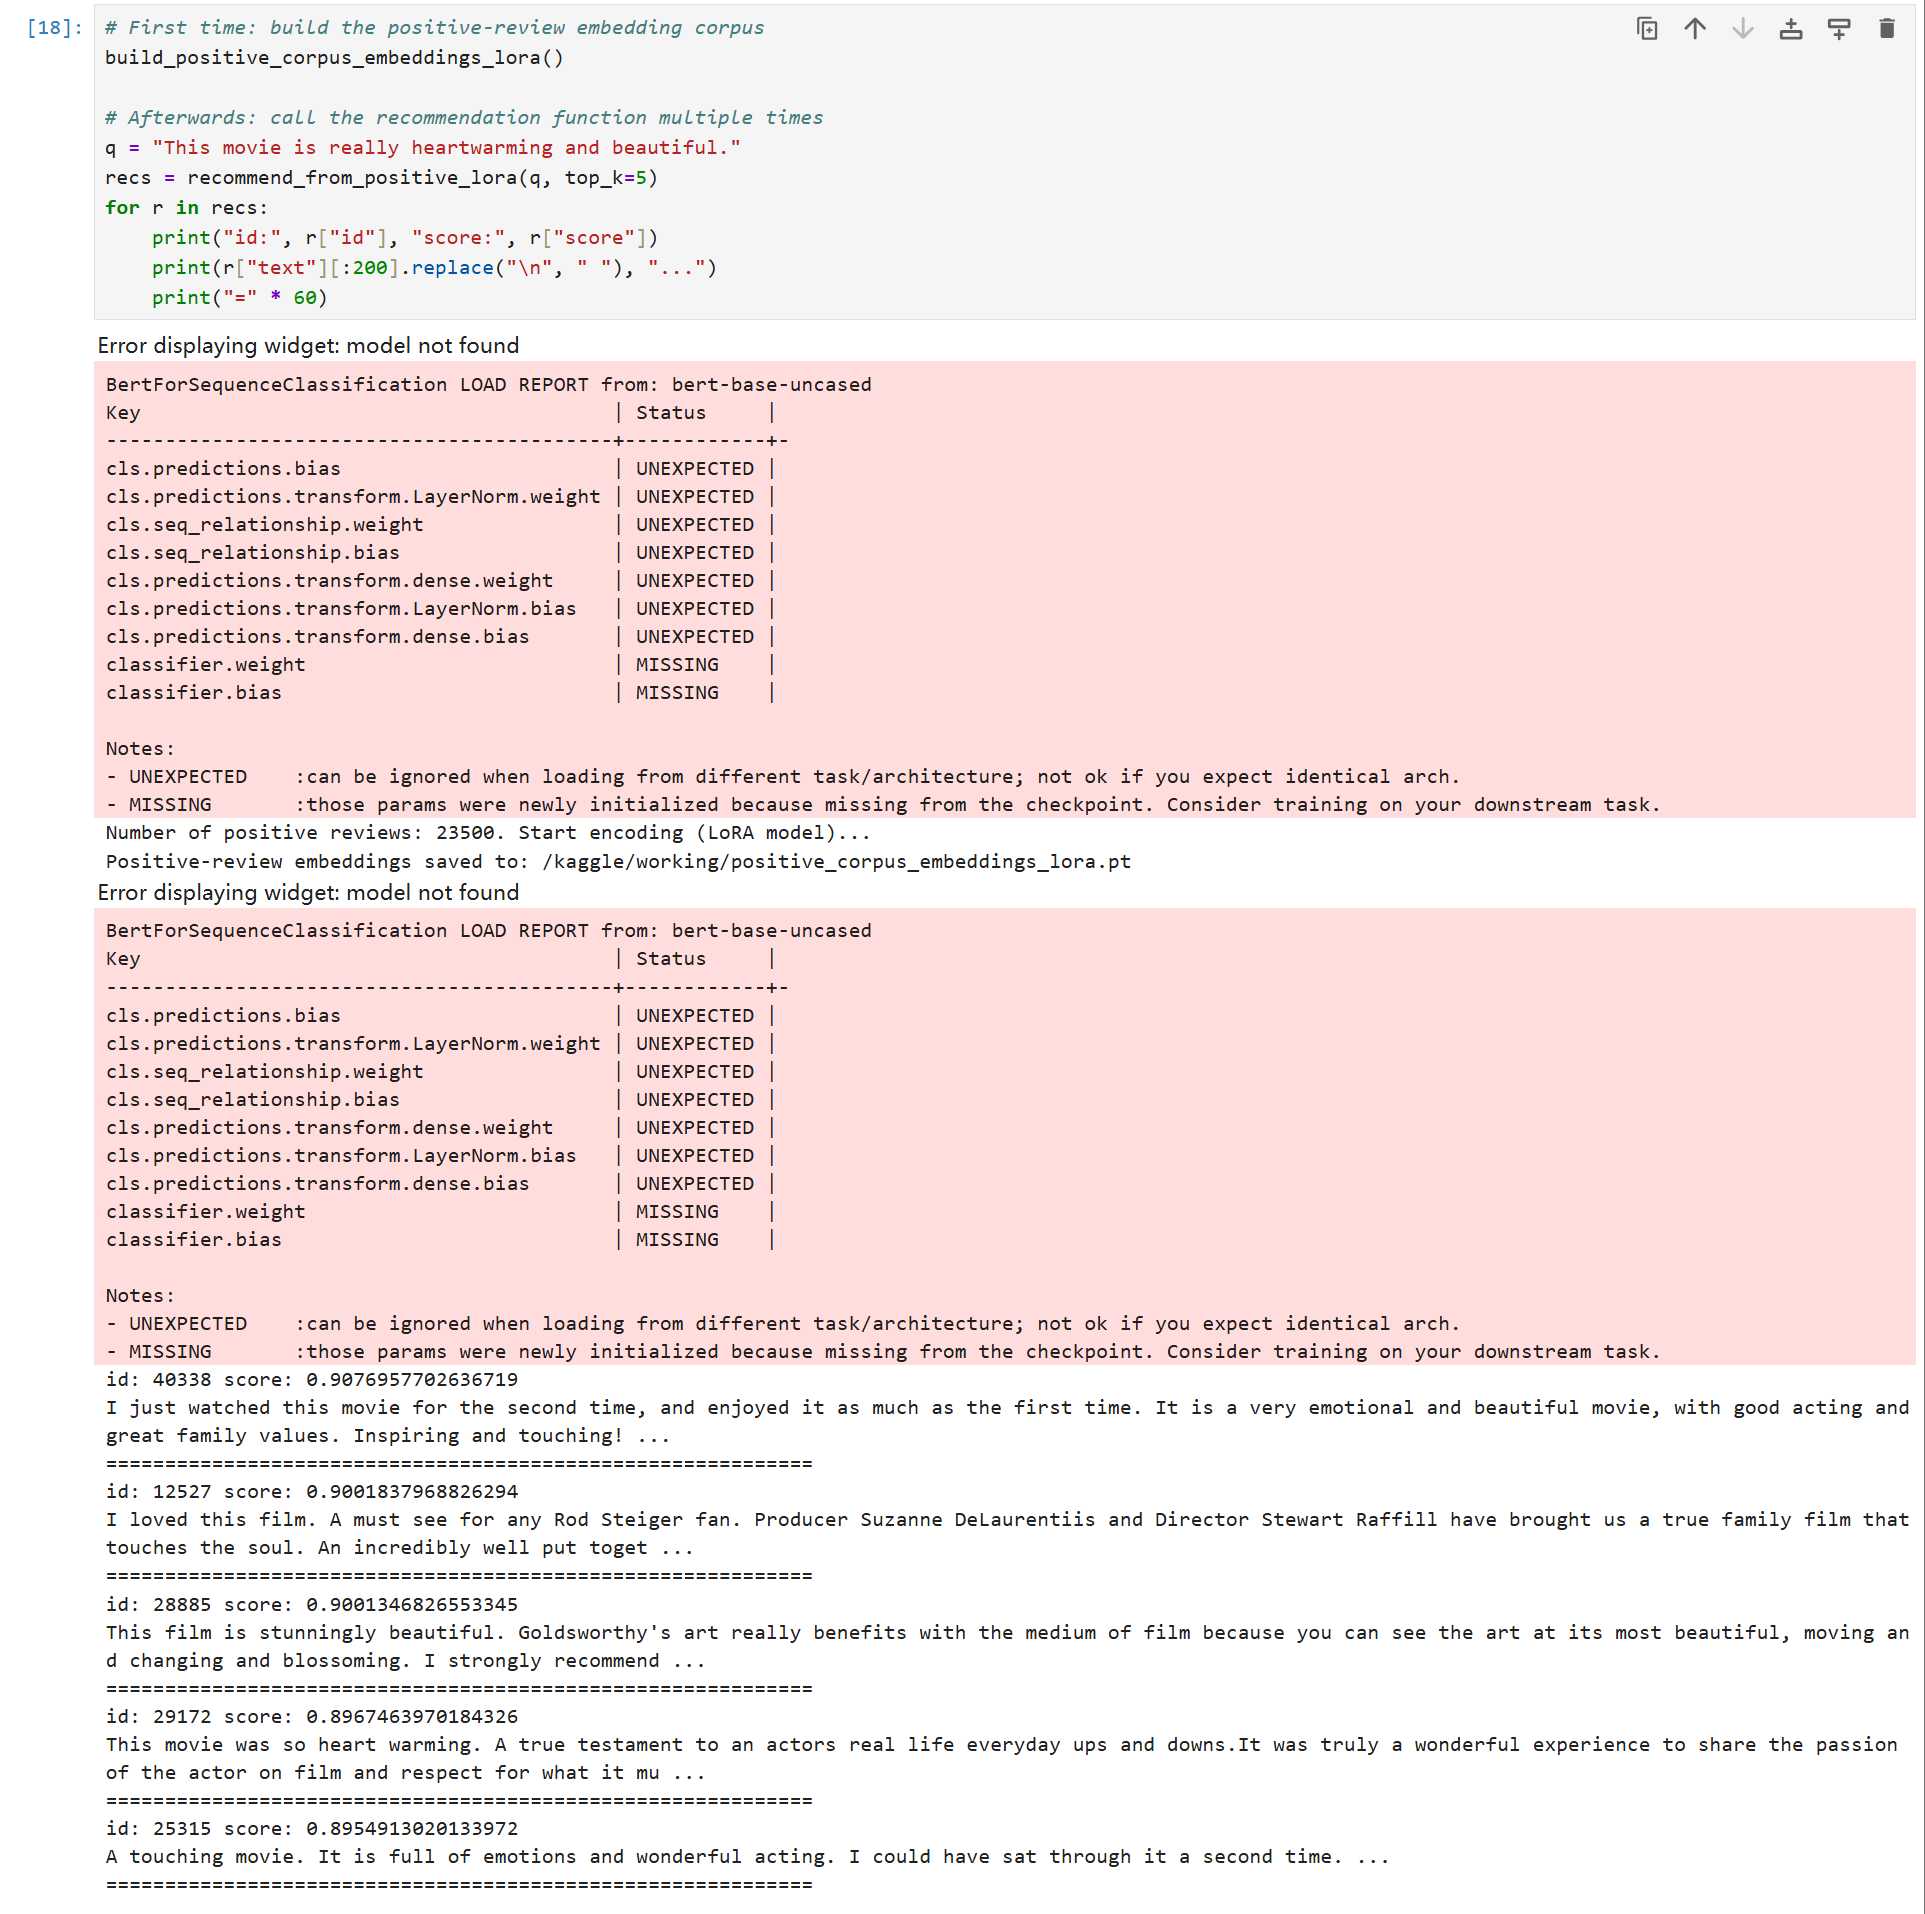